# Prompt Compression Benchmark Datasets - Demo Notebook

This notebook demonstrates the **Prompt Compression Benchmark Datasets** artifact, which provides 9 standardized datasets (33,790 examples total) for evaluating prompt compression techniques.

**Datasets included:**
- **GSM8K** - Math reasoning
- **HotpotQA** - Multi-hop QA
- **MuSiQue** - Multi-hop QA
- **SQuAD** - Extractive QA
- **ROPES** - Reading comprehension
- **ArXiv** - Summarization
- **GovReport** - Summarization
- **NarrativeQA** - Long-document QA
- **TriviaQA** - Open-domain QA

Each example contains:
- `input` (prompt with context)
- `output` (expected answer)
- `metadata_task_type`, `metadata_split`, `metadata_row_index`

This demo loads a curated mini subset (27 examples, 3 per dataset) for quick inspection.

In [1]:
# Install dependencies - following aii-colab pattern
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')
    _pip('loguru==0.7.3')

print("Install complete")


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


Install complete



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Imports - copied from original data.py plus notebook additions
from loguru import logger
import sys
import json
from pathlib import Path
from collections import defaultdict
import urllib.request

# NumPy 2.0 compatibility shim (for any non-Colab packages)
import numpy as np
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"): np.product = np.prod

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

print("Imports complete")

Imports complete


In [3]:
# Data loading helper - GitHub URL with local fallback
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9fe330-self-surprisal-hard-prompt-compression/main/round-2/dataset-1/demo/mini_demo_data.json"

def load_data():
    """Load mini_demo_data.json from GitHub or local file."""
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    local = Path("mini_demo_data.json")
    if local.exists():
        return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json from GitHub or local")

print("Data loader defined")

Data loader defined


In [4]:
# Load the data
data = load_data()

print(f"Loaded: {data['metadata']['description']}")
print(f"Total examples: {data['metadata']['total_examples']}")
print(f"Number of datasets: {data['metadata']['num_datasets']}")
print(f"Task types: {data['metadata']['task_types']}")
print()
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples (task_type: {ds['examples'][0]['metadata_task_type']})")

Loaded: Prompt Compression Benchmark Datasets (Mini Demo)
Total examples: 27
Number of datasets: 9
Task types: ['multi_hop_qa', 'summarization', 'long_document_qa', 'open_domain_qa', 'reading_comprehension', 'extractive_qa', 'math_reasoning']

  gsm8k: 3 examples (task_type: math_reasoning)
  hotpotqa: 3 examples (task_type: multi_hop_qa)
  musique: 3 examples (task_type: multi_hop_qa)
  squad: 3 examples (task_type: extractive_qa)
  ropes: 3 examples (task_type: reading_comprehension)
  arxiv: 3 examples (task_type: summarization)
  govreport: 3 examples (task_type: summarization)
  narrativeqa: 3 examples (task_type: long_document_qa)
  trivia_qa: 3 examples (task_type: open_domain_qa)


## Configuration

Tunable parameters for the demo. Kept at minimum values for fast execution.

In [5]:
# Config - absolute minimum values for demo
N_SAMPLES_PER_DATASET = 2       # Number of examples to show per dataset (min 1)
MAX_INPUT_PREVIEW = 200         # Max chars to show for input preview
MAX_OUTPUT_PREVIEW = 200        # Max chars to show for output preview
SHOW_FULL_EXAMPLES = False      # Set True to print full input/output (can be long)

print(f"Config: n_samples={N_SAMPLES_PER_DATASET}, max_preview={MAX_INPUT_PREVIEW}")

Config: n_samples=2, max_preview=200


## Data Exploration

Explore the loaded dataset structure and show sample examples from each dataset.

In [6]:
# Explore data structure - show sample from each dataset
for ds in data['datasets']:
    name = ds['dataset']
    examples = ds['examples']
    task_type = examples[0]['metadata_task_type']
    
    print(f"\n{'='*60}")
    print(f"Dataset: {name} | Task: {task_type} | Examples: {len(examples)}")
    print(f"{'='*60}")
    
    for i, ex in enumerate(examples[:N_SAMPLES_PER_DATASET]):
        inp = ex['input']
        out = ex['output']
        split = ex['metadata_split']
        
        print(f"\n--- Example {i+1} (split: {split}) ---")
        if SHOW_FULL_EXAMPLES:
            print(f"INPUT:\n{inp}")
            print(f"\nOUTPUT:\n{out}")
        else:
            print(f"INPUT: {inp[:MAX_INPUT_PREVIEW]}{'...' if len(inp) > MAX_INPUT_PREVIEW else ''}")
            print(f"OUTPUT: {out[:MAX_OUTPUT_PREVIEW]}{'...' if len(out) > MAX_OUTPUT_PREVIEW else ''}")


Dataset: gsm8k | Task: math_reasoning | Examples: 3

--- Example 1 (split: test) ---
INPUT: Three people invested $1200 in a joint savings account.  After Dylan's investment of 2/5 of the total amount, Frances invested 2/3 of the remaining amount.  Skyler's investment accounted for the rest....
OUTPUT: Dylan's investment was 2/5 * $1200 = $<<2/5*1200=480>>480
Frances and Skylers' investment was $1200 - $480 = $<<1200-480=720>>720
Frances invested 2/3 * $720 = $<<2/3*720=480>>480
Dylan's and Frances'...

--- Example 2 (split: test) ---
INPUT: Greta’s paycheck is $2400.00. She puts 50% of her pay into her retirement account. She then uses 20% of her paycheck to make her monthly car payment. After funding her retirement and paying for her ca...
OUTPUT: Her paycheck is $2400.00 and she puts 50% into her retirement so that’s 2400*.50 = $<<2400*.50=1200.00>>1200.00
Her paycheck is $2400.00 and she puts $1200 into retirement so that leaves 2400-1200 = $...

Dataset: hotpotqa | Task: multi_ho

## Statistics Summary

Compute and display aggregate statistics across all datasets.

In [7]:
# Statistics summary
print("\n" + "="*60)
print("DATASET STATISTICS")
print("="*60)

total_examples = 0
task_type_counts = defaultdict(int)
split_counts = defaultdict(int)

for ds in data['datasets']:
    name = ds['dataset']
    examples = ds['examples']
    n = len(examples)
    total_examples += n
    
    # Count task types and splits
    for ex in examples:
        task_type_counts[ex['metadata_task_type']] += 1
        split_counts[ex['metadata_split']] += 1
    
    # Input/output length stats
    input_lens = [len(ex['input']) for ex in examples]
    output_lens = [len(ex['output']) for ex in examples]
    
    print(f"\n{name}:")
    print(f"  Examples: {n}")
    print(f"  Input length:  mean={sum(input_lens)/n:.0f}, min={min(input_lens)}, max={max(input_lens)}")
    print(f"  Output length: mean={sum(output_lens)/n:.0f}, min={min(output_lens)}, max={max(output_lens)}")

print(f"\n{'='*60}")
print(f"TOTAL EXAMPLES: {total_examples}")
print(f"Task type distribution: {dict(task_type_counts)}")
print(f"Split distribution: {dict(split_counts)}")


DATASET STATISTICS

gsm8k:
  Examples: 3
  Input length:  mean=260, min=240, max=293
  Output length: mean=317, min=153, max=478

hotpotqa:
  Examples: 3
  Input length:  mean=5134, min=5066, max=5197
  Output length: mean=15, min=5, max=23

musique:
  Examples: 3
  Input length:  mean=4258, min=3200, max=4951
  Output length: mean=4, min=4, max=4

squad:
  Examples: 3
  Input length:  mean=876, min=865, max=882
  Output length: mean=18, min=14, max=23

ropes:
  Examples: 3
  Input length:  mean=1032, min=914, max=1192
  Output length: mean=0, min=0, max=0

arxiv:
  Examples: 3
  Input length:  mean=24598, min=17688, max=29979
  Output length: mean=927, min=363, max=1487

govreport:
  Examples: 3
  Input length:  mean=49389, min=32520, max=62077
  Output length: mean=3079, min=2371, max=4074

narrativeqa:
  Examples: 3
  Input length:  mean=5114, min=5105, max=5121
  Output length: mean=27, min=5, max=61

trivia_qa:
  Examples: 3
  Input length:  mean=67, min=54, max=76
  Output lengt

## Visualization

Plot example counts and length distributions across datasets.

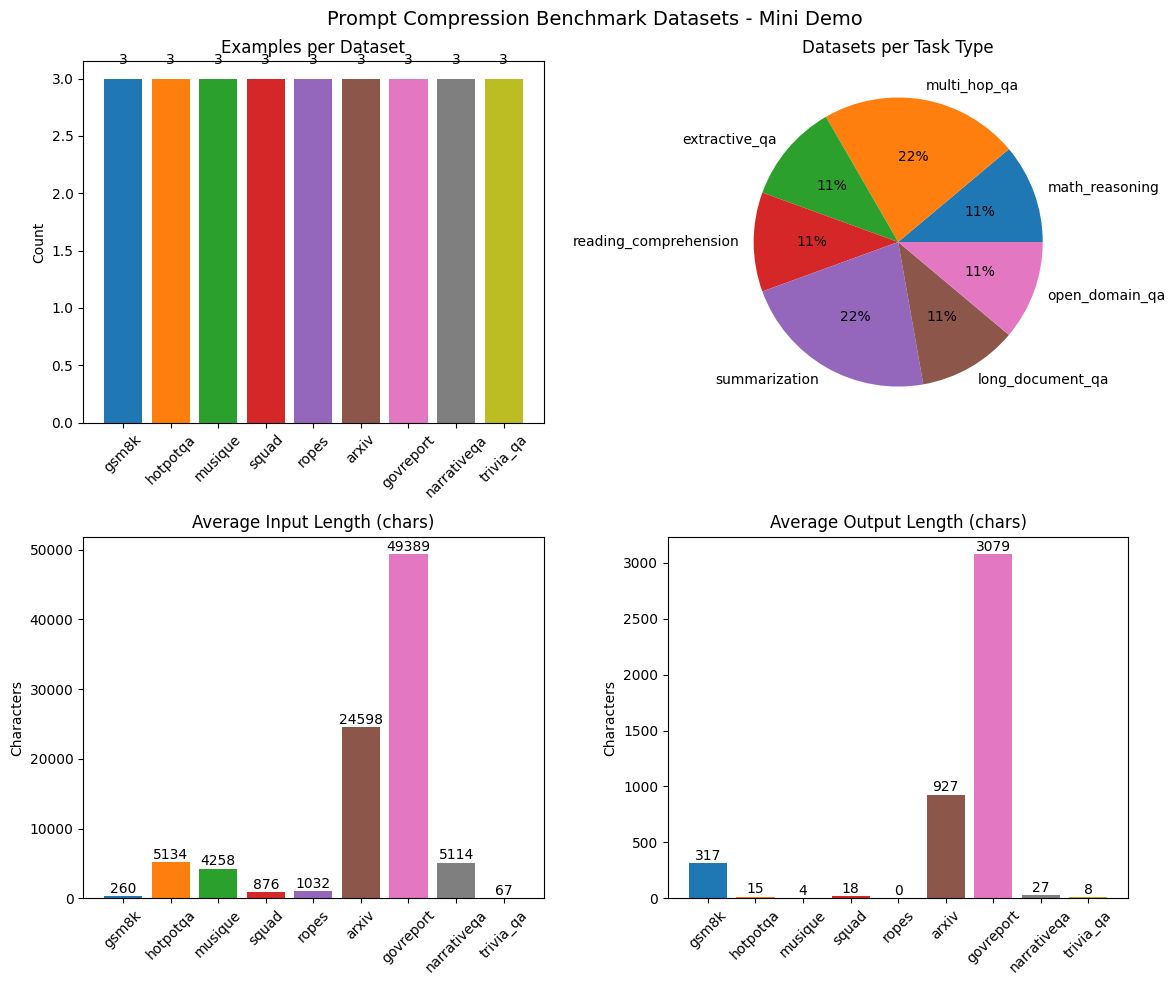

In [8]:
# Visualization with matplotlib
import matplotlib.pyplot as plt

# Prepare data for plotting
dataset_names = [ds['dataset'] for ds in data['datasets']]
example_counts = [len(ds['examples']) for ds in data['datasets']]
task_types = [ds['examples'][0]['metadata_task_type'] for ds in data['datasets']]

# Input/output lengths per dataset
input_means = []
output_means = []
for ds in data['datasets']:
    input_lens = [len(ex['input']) for ex in ds['examples']]
    output_lens = [len(ex['output']) for ex in ds['examples']]
    input_means.append(sum(input_lens) / len(input_lens))
    output_means.append(sum(output_lens) / len(output_lens))

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Prompt Compression Benchmark Datasets - Mini Demo', fontsize=14)

# 1. Example count per dataset
ax = axes[0, 0]
colors = plt.cm.tab10(range(len(dataset_names)))
bars = ax.bar(dataset_names, example_counts, color=colors)
ax.set_title('Examples per Dataset')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, example_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(count), ha='center', va='bottom')

# 2. Task type distribution
ax = axes[0, 1]
task_counts = defaultdict(int)
for tt in task_types:
    task_counts[tt] += 1
ax.pie(task_counts.values(), labels=task_counts.keys(), autopct='%1.0f%%', colors=colors[:len(task_counts)])
ax.set_title('Datasets per Task Type')

# 3. Average input length per dataset
ax = axes[1, 0]
bars = ax.bar(dataset_names, input_means, color=colors)
ax.set_title('Average Input Length (chars)')
ax.set_ylabel('Characters')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, input_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}', ha='center', va='bottom')

# 4. Average output length per dataset
ax = axes[1, 1]
bars = ax.bar(dataset_names, output_means, color=colors)
ax.set_title('Average Output Length (chars)')
ax.set_ylabel('Characters')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, output_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Reproduce Original Script Logic

This cell replicates the core logic from the original `data.py` script:
1. Group examples by dataset
2. Filter to the 9 best datasets
3. Build output in exp_sel_data_out schema format

This shows that the mini demo data already follows the same schema as the full output.

In [9]:
# Replicate original data.py logic
BEST_DATASETS = [
    "gsm8k",
    "hotpotqa",
    "musique",
    "squad",
    "ropes",
    "arxiv",
    "govreport",
    "narrativeqa",
    "trivia_qa",
]

def group_by_dataset(examples):
    """Group examples by dataset name (from original data.py)."""
    groups = defaultdict(list)
    for i, ex in enumerate(examples):
        dataset_name = ex.get("dataset", "unknown")
        groups[dataset_name].append({
            "input": ex.get("prompt", ""),
            "output": ex.get("answer", ""),
            "metadata_task_type": ex.get("task_type", "unknown"),
            "metadata_split": ex.get("split", "unknown"),
            "metadata_row_index": i,
        })
    return groups

def build_output(groups):
    """Build the exp_sel_data_out schema structure (from original data.py)."""
    datasets = []
    for dataset_name, examples in sorted(groups.items()):
        if dataset_name not in BEST_DATASETS:
            continue
        datasets.append({
            "dataset": dataset_name,
            "examples": examples,
        })
    return {
        "metadata": {
            "description": "Prompt Compression Benchmark Datasets",
            "total_examples": sum(len(d["examples"]) for d in datasets),
            "num_datasets": len(datasets),
            "task_types": list(set(
                ex.get("metadata_task_type", "")
                for d in datasets
                for ex in d["examples"]
            )),
        },
        "datasets": datasets,
    }

# Since our mini_demo_data.json is already in the final schema format,
# we just verify it matches
print("Original schema verification:")
print(f"  Datasets in mini_demo: {[ds['dataset'] for ds in data['datasets']]}")
print(f"  All in BEST_DATASETS: {all(ds['dataset'] in BEST_DATASETS for ds in data['datasets'])}")
print(f"  Total examples: {data['metadata']['total_examples']}")
print(f"  Task types: {data['metadata']['task_types']}")

# Show the schema structure
print("\nSchema structure:")
print(f"  metadata: {list(data['metadata'].keys())}")
print(f"  datasets[0] keys: {list(data['datasets'][0].keys())}")
print(f"  datasets[0].examples[0] keys: {list(data['datasets'][0]['examples'][0].keys())}")

Original schema verification:
  Datasets in mini_demo: ['gsm8k', 'hotpotqa', 'musique', 'squad', 'ropes', 'arxiv', 'govreport', 'narrativeqa', 'trivia_qa']
  All in BEST_DATASETS: True
  Total examples: 27
  Task types: ['multi_hop_qa', 'summarization', 'long_document_qa', 'open_domain_qa', 'reading_comprehension', 'extractive_qa', 'math_reasoning']

Schema structure:
  metadata: ['description', 'total_examples', 'num_datasets', 'task_types']
  datasets[0] keys: ['dataset', 'examples']
  datasets[0].examples[0] keys: ['input', 'output', 'metadata_task_type', 'metadata_split', 'metadata_row_index']


## Summary

This demo notebook demonstrates:

1. **Loading** the mini demo data from GitHub (with local fallback)
2. **Exploring** the 9 benchmark datasets with 3 examples each (27 total)
3. **Statistics** on input/output lengths, task types, and splits
4. **Visualizations** of dataset sizes and length distributions
5. **Schema verification** matching the original `data.py` output format

The full artifact contains **33,790 examples** across the same 9 datasets, split into two files (90MB + 65MB) to stay under 100MB limits. Mini and preview variants are included for quick inspection.

To use the full dataset, replace `mini_demo_data.json` with the full data files from the artifact's `full_data_out/` directory.